# PCA — Team Style Dimensionality Reduction
Reduces 18 team features to principal components.

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
FEATURE_COLS = [
    'three_pt_attempt_rate', 'three_pt_pct', 'two_pt_pct', 'ft_point_rate',
    'fga_per_possession', 'turnover_rate', 'oreb_rate', 'transition_rate', 'off_rating',
    'opp_three_pt_attempt_rate', 'opp_two_pt_pct', 'opp_turnover_rate', 'opp_oreb_rate',
    'def_rating', 'avg_pace', 'weighted_off_rapm', 'star_concentration', 'rotation_depth'
]

df = pd.read_csv('data/team_features.csv')
df = df.set_index('abbrev')
X = df[FEATURE_COLS].values
teams = df.index.tolist()
print(f"Loaded {len(teams)} teams, {len(FEATURE_COLS)} features")

Loaded 30 teams, 18 features


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

os.makedirs('data', exist_ok=True)

df_normalized = pd.DataFrame(X_scaled, index=teams, columns=FEATURE_COLS)
df_normalized.index.name = 'abbrev'
df_normalized.to_csv('data/team_features_normalized.csv')
print(f"Scaled {X_scaled.shape[0]} teams x {X_scaled.shape[1]} features")
print(f"Saved data/team_features_normalized.csv")

Scaled 30 teams x 18 features
Saved data/team_features_normalized.csv


## PCA — Explained Variance

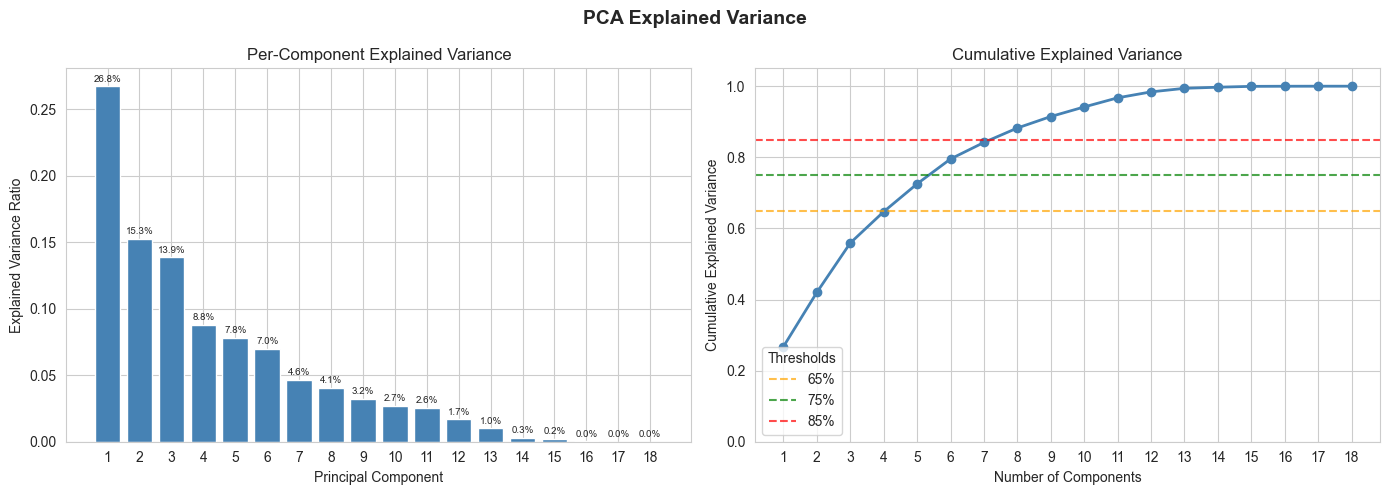

In [4]:
pca_full = PCA(n_components=18, random_state=42)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumvar = np.cumsum(evr)
components = np.arange(1, 19)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-component bar chart
ax = axes[0]
bars = ax.bar(components, evr, color='steelblue', edgecolor='white')
for bar, v in zip(bars, evr):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{v:.1%}', ha='center', va='bottom', fontsize=7)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Per-Component Explained Variance')
ax.set_xticks(components)

# Right: cumulative curve
ax = axes[1]
ax.plot(components, cumvar, marker='o', color='steelblue', linewidth=2)
for thresh, color, label in [(0.65, 'orange', '65%'), (0.75, 'green', '75%'), (0.85, 'red', '85%')]:
    ax.axhline(thresh, linestyle='--', color=color, alpha=0.7, label=label)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Explained Variance')
ax.set_xticks(components)
ax.set_ylim(0, 1.05)
ax.legend(title='Thresholds')

fig.suptitle('PCA Explained Variance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/pca_scree.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
for n in [2, 3, 4, 5, 6]:
    print(f"  {n} components: {cumvar[n-1]:.1%} variance explained")

N_COMPONENTS = next(n for n in range(2, 18) if cumvar[n-1] >= 0.70)
print(f"\nUsing N_COMPONENTS = {N_COMPONENTS} (>= 70% variance)")

  2 components: 42.0% variance explained
  3 components: 55.9% variance explained
  4 components: 64.7% variance explained
  5 components: 72.5% variance explained
  6 components: 79.5% variance explained

Using N_COMPONENTS = 5 (>= 70% variance)


## PC1 vs PC2 Biplot

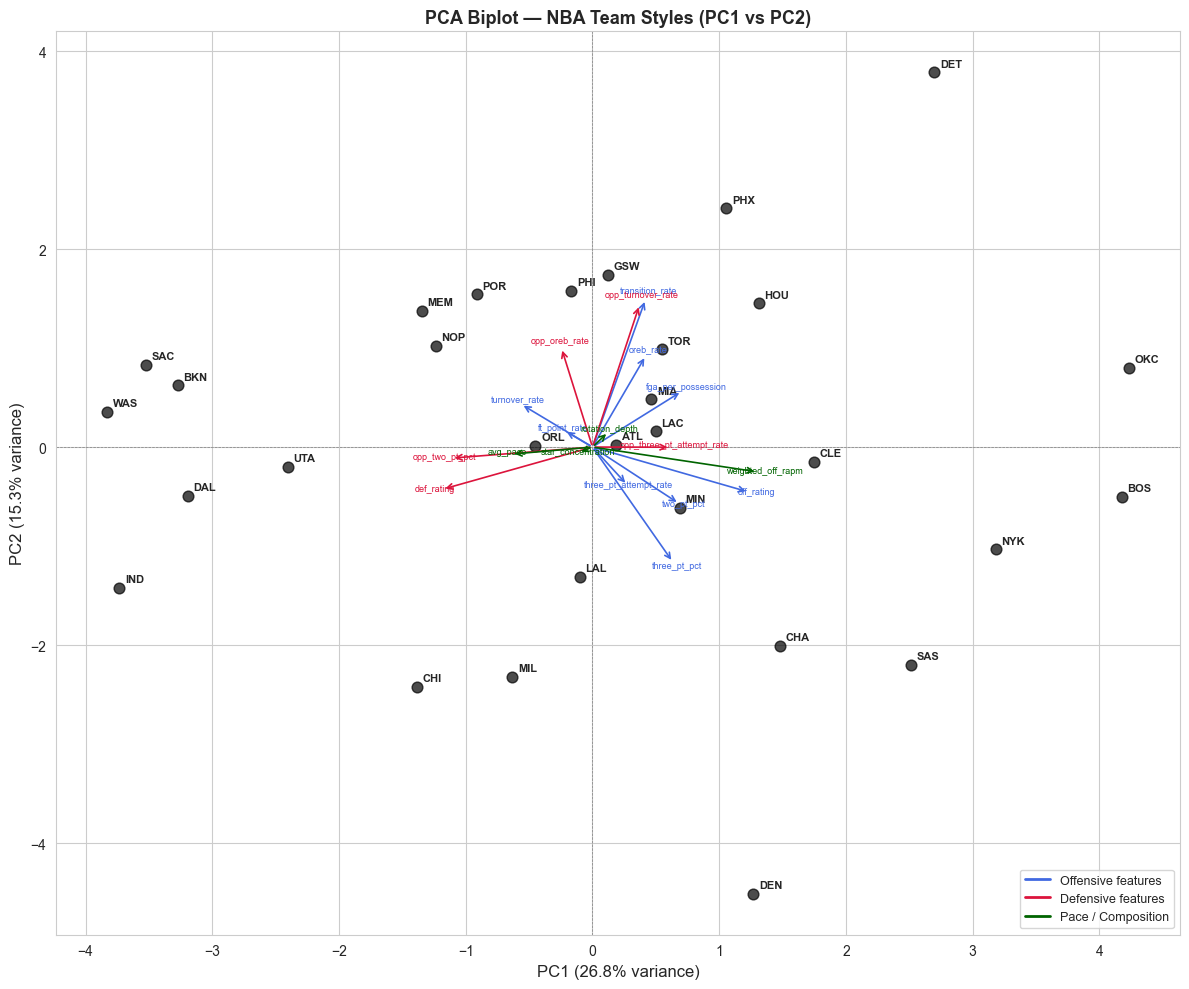

In [6]:
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Feature groupings for arrow colors
offensive_feats = {
    'three_pt_attempt_rate', 'three_pt_pct', 'two_pt_pct', 'ft_point_rate',
    'fga_per_possession', 'turnover_rate', 'oreb_rate', 'transition_rate', 'off_rating'
}
defensive_feats = {
    'opp_three_pt_attempt_rate', 'opp_two_pt_pct', 'opp_turnover_rate',
    'opp_oreb_rate', 'def_rating'
}
# pace/composition
other_feats = {'avg_pace', 'weighted_off_rapm', 'star_concentration', 'rotation_depth'}

def feat_color(feat: str) -> str:
    if feat in offensive_feats:
        return 'royalblue'
    if feat in defensive_feats:
        return 'crimson'
    return 'darkgreen'

loadings = pca.components_.T  # shape (18, N_COMPONENTS)
arrow_scale = 3.0

fig, ax = plt.subplots(figsize=(12, 10))

# Scatter teams
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=60, color='black', zorder=3, alpha=0.7)
for i, team in enumerate(teams):
    ax.annotate(team, (X_pca[i, 0], X_pca[i, 1]),
                textcoords='offset points', xytext=(4, 4), fontsize=8, fontweight='bold')

# Overlay loading arrows
for j, feat in enumerate(FEATURE_COLS):
    dx = loadings[j, 0] * arrow_scale
    dy = loadings[j, 1] * arrow_scale
    color = feat_color(feat)
    ax.annotate('', xy=(dx, dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    ax.text(dx * 1.05, dy * 1.05, feat, fontsize=6.5, color=color, ha='center')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA Biplot — NBA Team Styles (PC1 vs PC2)', fontsize=13, fontweight='bold')

# Legend for arrow colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='royalblue', lw=2, label='Offensive features'),
    Line2D([0], [0], color='crimson',   lw=2, label='Defensive features'),
    Line2D([0], [0], color='darkgreen', lw=2, label='Pace / Composition'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('data/pca_biplot.png', dpi=100, bbox_inches='tight')
plt.show()

## PC Loadings Interpretation

In [7]:
for pc_idx in range(min(3, N_COMPONENTS)):
    pc_loadings = pca.components_[pc_idx]  # shape (18,)
    sorted_idx = np.argsort(pc_loadings)[::-1]  # descending
    evr_pc = pca.explained_variance_ratio_[pc_idx]

    print(f"\nPC{pc_idx+1} ({evr_pc:.1%} variance explained)")
    print(f"{'Feature':<32} {'Loading':>8}")
    print("-" * 42)
    print("  Top 5 positive:")
    for i in sorted_idx[:5]:
        print(f"    {FEATURE_COLS[i]:<30} {pc_loadings[i]:>+8.3f}")
    print("  Top 5 negative:")
    for i in sorted_idx[-5:][::-1]:
        print(f"    {FEATURE_COLS[i]:<30} {pc_loadings[i]:>+8.3f}")


PC1 (26.8% variance explained)
Feature                           Loading
------------------------------------------
  Top 5 positive:
    weighted_off_rapm                +0.433
    off_rating                       +0.410
    fga_per_possession               +0.235
    two_pt_pct                       +0.228
    three_pt_pct                     +0.212
  Top 5 negative:
    def_rating                       -0.394
    opp_two_pt_pct                   -0.370
    avg_pace                         -0.212
    turnover_rate                    -0.188
    opp_oreb_rate                    -0.082

PC2 (15.3% variance explained)
Feature                           Loading
------------------------------------------
  Top 5 positive:
    transition_rate                  +0.498
    opp_turnover_rate                +0.480
    opp_oreb_rate                    +0.334
    oreb_rate                        +0.307
    fga_per_possession               +0.187
  Top 5 negative:
    three_pt_pct                  

## PC Axis Interpretations

Fill in after viewing the biplot and loadings table above.

**PC1 (___% variance):**
- Positive end: ___
- Negative end: ___

**PC2 (___% variance):**
- Positive end: ___
- Negative end: ___

**PC3 (___% variance):**
- Positive end: ___
- Negative end: ___

*(e.g. PC1 positive = high 3PA rate / perimeter-heavy offense; negative = paint-heavy / physical teams)*

In [8]:
os.makedirs('data', exist_ok=True)

pca_data = {
    'scaler': scaler,
    'pca': pca,
    'feature_cols': FEATURE_COLS,
    'n_components': N_COMPONENTS,
    'X_pca': X_pca,  # shape (30, N_COMPONENTS)
    'teams': teams,
}
with open('data/pca_model.pkl', 'wb') as f:
    pickle.dump(pca_data, f)

print(f"Saved PCA model: {N_COMPONENTS} components, {len(teams)} teams")
print(f"X_pca shape: {X_pca.shape}")

Saved PCA model: 5 components, 30 teams
X_pca shape: (30, 5)
